/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Class Proportions:
Malignant: 5590 Benign: 6289


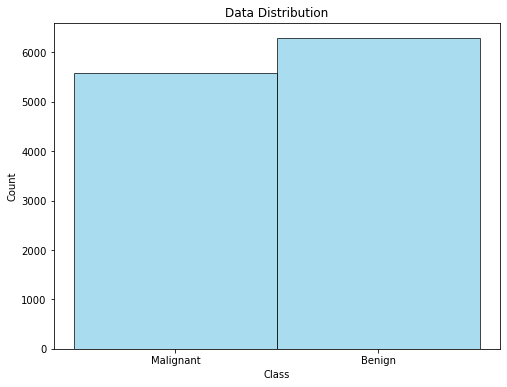

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Define constants
data_path = r'/home/lab5/Downloads/train'
target_size = (150, 150)  # Define the target size for resizing
#kernal is dieing while using (224,244) so i modified to (150)
# Load and preprocess data
images = []
labels = []

# Loop through each class (Malignant and Benign)
for class_name in ['Benign', 'Malignant']:
    class_path = os.path.join(data_path, class_name)
    # Iterate through each image in the class
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        # Read the image in grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        # Resize the image to the target size
        img = cv2.resize(img, target_size)
        # Normalize the pixel values to the range [0, 1]
        img = img.astype(np.float32) / 255.0
        # Append the preprocessed image to the images list
        images.append(img)
        # Append the label (0 for Malignant, 1 for Benign) to the labels list
        labels.append(0 if class_name == 'Malignant' else 1)

# Convert images and labels to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Print class proportions
print("Class Proportions:")
print("Malignant:", np.sum(labels == 0), "Benign:", np.sum(labels == 1))

# Plot histogram for class distribution
plt.figure(figsize=(8, 6))
plt.hist(labels, bins=2, color='skyblue', edgecolor='black', alpha=0.7)
plt.xticks([0.25, 0.75], ['Malignant', 'Benign'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Data Distribution')
plt.show()


In [2]:
# Separate data for Malignant and Benign classes
malignant_images = images[labels == 0][:2000]
benign_images = images[labels == 1][:2000]
malignant_labels = labels[labels == 0][:2000]
benign_labels = labels[labels == 1][:2000]

# Concatenate the data back together
balanced_images = np.concatenate([malignant_images, benign_images])
balanced_labels = np.concatenate([malignant_labels, benign_labels])

# Split the balanced dataset into training and testing sets

# Split the data into training and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(balanced_images, balanced_labels, test_size=0.2, random_state=42)

# Split the training data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)


#print the balanced data
print("Balanced Images:", balanced_images.shape)
print("Balanced labels:", balanced_labels.shape)

#print the data separately of each class
print("malignant_images:", malignant_images.shape)
print("benign_images:", benign_images.shape)

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("y_valid shape:", y_valid.shape)


Balanced Images: (4000, 150, 150)
Balanced labels: (4000,)
malignant_images: (2000, 150, 150)
benign_images: (2000, 150, 150)
X_train shape: (2880, 150, 150)
X_valid shape: (320, 150, 150)
X_test shape: (800, 150, 150)
y_train shape: (2880,)
y_test shape: (800,)
y_valid shape: (320,)


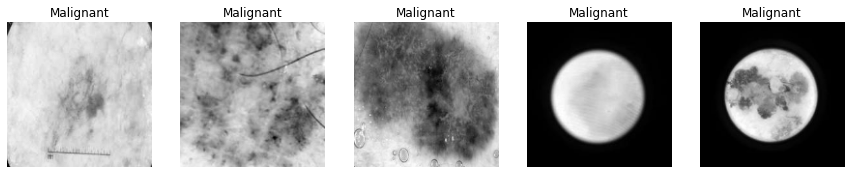

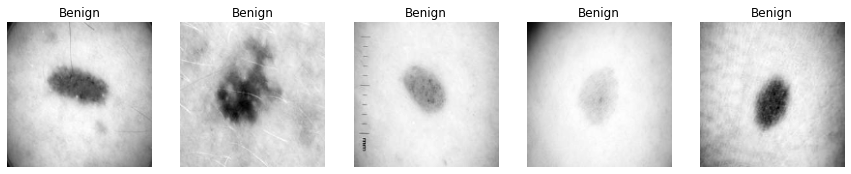

In [3]:
# Display preprocessed images
num_images_to_display = 5  # Number of images to display for each class

# Loop through each class
for class_name in ['Malignant', 'Benign']:
    class_path = os.path.join(data_path, class_name)
    class_indices = np.where(labels == (0 if class_name == 'Malignant' else 1))[0]
    class_indices_to_display = np.random.choice(class_indices, num_images_to_display, replace=False)
    
    # Display images
    plt.figure(figsize=(15, 3))
    for i, image_index in enumerate(class_indices_to_display):
        image = images[image_index]
        plt.subplot(1, num_images_to_display, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(class_name)
        plt.axis('off')
    plt.show()


2024-03-24 11:03:44.046232: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-24 11:03:44.046685: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-24 11:03:44.065474: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-24 11:03:44.193525: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-24 11:03:44.653588: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.6688 - loss: 0.5842 - val_accuracy: 0.8156 - val_loss: 0.4407
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7786 - loss: 0.4592 - val_accuracy: 0.8438 - val_loss: 0.4134
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8173 - loss: 0.4142 - val_accuracy: 0.8406 - val_loss: 0.3962
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8092 - loss: 0.4091 - val_accuracy: 0.8438 - val_loss: 0.3846
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.8270 - loss: 0.4013 - val_accuracy: 0.8469 - val_loss: 0.3704
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8244 - loss: 0.3902 - val_accuracy: 0.8531 - val_loss: 0.3589
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8230 - loss: 0.3919 - val_accuracy: 0.8344 - val_loss: 0.3603
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8297 - loss: 0.3747 - val_accuracy: 0.8469 - v

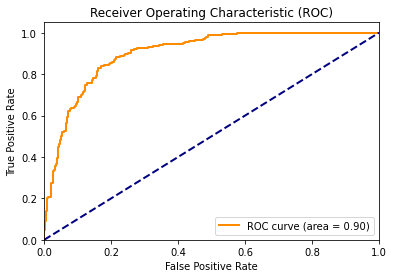

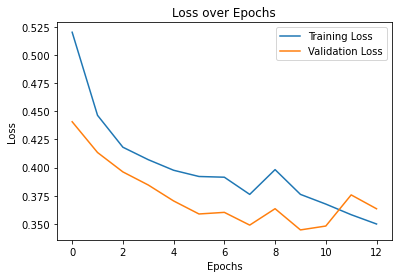

Accuracy: 0.8275
Precision: 0.7926829268292683
Recall: 0.8597883597883598
F1 Score: 0.8248730964467005
Confusion Matrix:
[[337  85]
 [ 53 325]]
Cohen's Kappa: 0.6554737236300088
Matthews Correlation Coefficient: 0.6575755496984008
Balanced Accuracy: 0.8291832794202463
True Positives: 325
True Negatives: 337
False Positives: 85
False Negatives: 53
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8446 - loss: 0.3682
Test Accuracy: 82.75%
Test Loss: 39.03%
Execution time: 1667.6028213500977
Metrics saved to metrics.csv file.


In [3]:
#    GlobalAveragePooling2D+Dense (512 units, ReLU activation)+Dense (1 unit, sigmoid activation)
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import cv2
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Start time
start_time = time.time()

# Assuming you have X_train, X_test, y_train, and y_test
# Modify the data shapes based on the model requirements
X_train_resized = np.array([cv2.resize(img, (224, 224)) for img in X_train])
X_train_resized = np.repeat(X_train_resized[..., np.newaxis], 3, -1)
X_valid_resized = np.array([cv2.resize(img, (224, 224)) for img in X_valid])
X_valid_resized = np.repeat(X_valid_resized[..., np.newaxis], 3, -1)
# Example: Assuming X_test is another dataset
X_test_resized = np.array([cv2.resize(img, (224, 224)) for img in X_test])
X_test_resized = np.repeat(X_test_resized[..., np.newaxis], 3, -1)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model with Adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)



# Train the model with early stopping and 10 epochs (change as needed)
history = model.fit(X_train_resized, y_train, batch_size=32, epochs=25, validation_data=(X_valid_resized, y_valid), callbacks=[early_stopping])

# Predict probabilities for test labels
predicted_probabilities = model.predict(X_test_resized)

# Convert probabilities to classes (0 or 1)
predicted_labels = (predicted_probabilities > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels)
recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
conf_matrix = confusion_matrix(y_test, predicted_labels)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot loss and epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Print Metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
# Calculate Cohen's Kappa
total_agreements = conf_matrix[0, 0] + conf_matrix[1, 1]
total = np.sum(conf_matrix)
po = total_agreements / total
pe = ((np.sum(conf_matrix[0]) / total) * (np.sum(conf_matrix[:, 0]) / total)) + ((np.sum(conf_matrix[1]) / total) * (np.sum(conf_matrix[:, 1]) / total))
kappa = (po - pe) / (1 - pe)

# Calculate Matthews Correlation Coefficient
tp = conf_matrix[1, 1]
tn = conf_matrix[0, 0]
fp = conf_matrix[0, 1]
fn = conf_matrix[1, 0]
mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

# Calculate Balanced Accuracy
sensitivity = recall_score(y_test, predicted_labels)
specificity = tn / (tn + fp)
balanced_accuracy = (sensitivity + specificity) / 2
# Print Additional Metrics
print(f"Cohen's Kappa: {kappa}")
print(f"Matthews Correlation Coefficient: {mcc}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss * 100:.2f}%')

# Measure the end time
end_time = time.time()
execution_time = end_time - start_time

print("Execution time:", execution_time)
# Save metrics to DataFrame
# Save metrics to DataFrame
metrics = {
    'Combination':'1',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Test Accuracy': test_accuracy * 100,
    'Test Loss': test_loss * 100,
    'Validation Accuracy': history.history['val_accuracy'][-1],
    'Validation Loss': history.history['val_loss'][-1],
    "Cohen's Kappa": kappa,
    'Matthews Correlation': mcc,
    'Balanced Accuracy': balanced_accuracy,
    'True Positives': tp,
    'True Negatives': tn,
    'False Positives': fp,
    'False Negatives': fn,
    'Execution Time (s)': execution_time
}
metrics_df = pd.DataFrame(metrics, index=[0])

# Save DataFrame to CSV
metrics_df.to_csv('VGG16_2000_epoch_25_metrics.csv', index=False)

print("Metrics saved to metrics.csv file.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,560,769 (105.14 MB)

 Trainable params: 12,846,081 (49.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6652 - loss: 1.3051 - val_accuracy: 0.8531 - val_loss: 0.3724
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8401 - loss: 0.3593 - val_accuracy: 0.8156 - val_loss: 0.4037
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8467 - loss: 0.3289 - val_accuracy: 0.8281 - val_loss: 0.3814
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8597 - loss: 0.3118 - val_accuracy: 0.8469 - val_loss: 0.3356
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.9013 - loss: 0.2539 - val_accuracy: 0.8469 - val_loss: 0.3721
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8958 - loss: 0.2457 - val_accuracy: 0.7844 - val_loss: 0.5128
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8934 - loss: 0.2562 - val_accuracy: 0.8531 - val_loss: 0.3379
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
25/25 ━━━━━━━━━━━━━━━━━━━━ 3

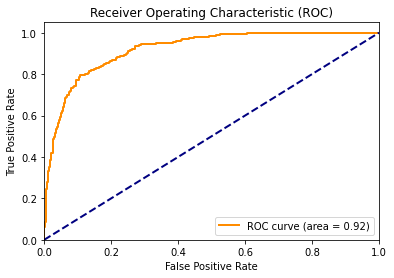

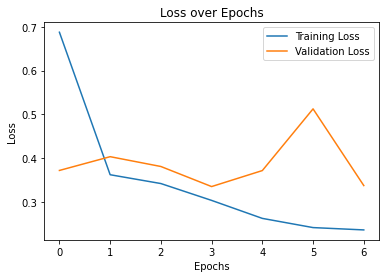

Accuracy: 0.83
Precision: 0.7951219512195122
Recall: 0.8624338624338624
F1 Score: 0.8274111675126903
Confusion Matrix:
[[338  84]
 [ 52 326]]
Cohen's Kappa: 0.6604668580701536
Matthews Correlation: 0.6625846950017594
Balanced Accuracy: 0.8316908648662203
True Positives: 326
True Negatives: 338
False Positives: 84
False Negatives: 52
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8394 - loss: 0.3464
Test Accuracy: 83.00%
Test Loss: 35.93%
Execution time: 951.5889618396759
Metrics appended to metrics.csv file.


In [4]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Flatten  # Import Flatten layer
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import cv2
import time

from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score
# Start time
start_time = time.time()

# Assuming you have X_train, X_test, y_train, and y_test
# Modify the data shapes based on the model requirements
X_train_resized = np.array([cv2.resize(img, (224, 224)) for img in X_train])
X_train_resized = np.repeat(X_train_resized[..., np.newaxis], 3, -1)
X_valid_resized = np.array([cv2.resize(img, (224, 224)) for img in X_valid])
X_valid_resized = np.repeat(X_valid_resized[..., np.newaxis], 3, -1)
# Example: Assuming X_test is another dataset
X_test_resized = np.array([cv2.resize(img, (224, 224)) for img in X_test])
X_test_resized = np.repeat(X_test_resized[..., np.newaxis], 3, -1)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)  # Use Flatten layer
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model with Adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)



# Train the model with early stopping and 10 epochs (change as needed)
history = model.fit(X_train_resized, y_train, batch_size=32, epochs=25, validation_data=(X_valid_resized, y_valid), callbacks=[early_stopping])

# Predict probabilities for test labels
predicted_probabilities = model.predict(X_test_resized)

# Convert probabilities to classes (0 or 1)
predicted_labels = (predicted_probabilities > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels)
recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
conf_matrix = confusion_matrix(y_test, predicted_labels)


# Calculate additional metrics
kappa = cohen_kappa_score(y_test, predicted_labels)
mcc = matthews_corrcoef(y_test, predicted_labels)
balanced_accuracy = balanced_accuracy_score(y_test, predicted_labels)

# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = confusion_matrix(y_test, predicted_labels).ravel()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities)
roc_auc = auc(fpr, tpr)


# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot loss and epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Print Metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print(f"Cohen's Kappa: {kappa}")
print(f"Matthews Correlation: {mcc}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss * 100:.2f}%')

# Measure the end time
end_time = time.time()
execution_time = end_time - start_time

print("Execution time:", execution_time)

# Load the existing metrics.csv file into a DataFrame
existing_metrics_df = pd.read_csv('VGG16_2000_epoch_25_metrics.csv')
# Create a DataFrame with the new metrics and execution time
new_metrics_dict = {
    'Combination': ['2'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'Test Accuracy': [test_accuracy * 100],
    'Test Loss': [test_loss * 100],
    'Validation Accuracy': history.history['val_accuracy'][-1],
    'Validation Loss': history.history['val_loss'][-1],
    'Cohen\'s Kappa': [kappa],
    'Matthews Correlation': [mcc],
    'Balanced Accuracy': [balanced_accuracy],
    'True Positives': [tp],
    'True Negatives': [tn],
    'False Positives': [fp],
    'False Negatives': [fn],
    'Execution Time (s)': [execution_time]
}

new_metrics_df = pd.DataFrame(new_metrics_dict)

# Concatenate the existing DataFrame with the new DataFrame
updated_metrics_df = pd.concat([existing_metrics_df, new_metrics_df], ignore_index=True)

# Save the updated DataFrame back to the CSV file
updated_metrics_df.to_csv('VGG16_2000_epoch_25_metrics.csv', index=False)

print("Metrics appended to metrics.csv file.")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 64)       │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,141,761 (57.76 MB)

 Trainable params: 427,073 (1.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7154 - loss: 0.5343 - val_accuracy: 0.8094 - val_loss: 0.4321
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.8194 - loss: 0.4018 - val_accuracy: 0.8375 - val_loss: 0.3725
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8638 - loss: 0.3278 - val_accuracy: 0.8313 - val_loss: 0.3634
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8699 - loss: 0.3045 - val_accuracy: 0.8469 - val_loss: 0.3573
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9014 - loss: 0.2553 - val_accuracy: 0.8500 - val_loss: 0.3812
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8916 - loss: 0.2466 - val_accuracy: 0.8562 - val_loss: 0.3570
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9248 - loss: 0.1974 - val_accuracy: 0.8281 - val_loss: 0.4481
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9123 - loss: 0.2039 - val_accuracy: 0.8313 - v

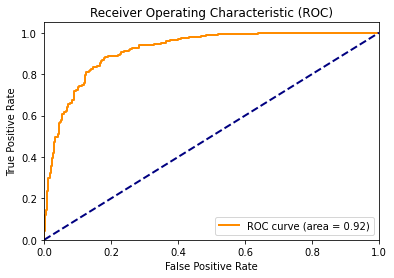

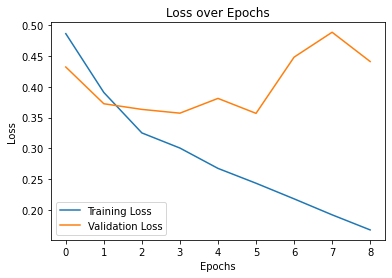

Accuracy: 0.84125
Precision: 0.8193384223918575
Recall: 0.8518518518518519
F1 Score: 0.8352788586251622
Confusion Matrix:
[[351  71]
 [ 56 322]]
Cohen's Kappa: 0.6821941118326389
Matthews Correlation: 0.6826752127117208
Balanced Accuracy: 0.8418027031771107
True Positives: 322
True Negatives: 351
False Positives: 71
False Negatives: 56
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8397 - loss: 0.3645
Test Accuracy: 84.13%
Test Loss: 36.30%
Execution time: 1163.1075959205627
Metrics appended to metrics.csv file.


In [5]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Flatten, Conv2D, MaxPooling2D  # Add imports
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import cv2
import time
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Start time
start_time = time.time()

# Assuming you have X_train, X_test, y_train, and y_test
# Modify the data shapes based on the model requirements
X_train_resized = np.array([cv2.resize(img, (224, 224)) for img in X_train])
X_train_resized = np.repeat(X_train_resized[..., np.newaxis], 3, -1)
X_valid_resized = np.array([cv2.resize(img, (224, 224)) for img in X_valid])
X_valid_resized = np.repeat(X_valid_resized[..., np.newaxis], 3, -1)
# Example: Assuming X_test is another dataset
X_test_resized = np.array([cv2.resize(img, (224, 224)) for img in X_test])
X_test_resized = np.repeat(X_test_resized[..., np.newaxis], 3, -1)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=output)


# Compile the model with Adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)


# Train the model with early stopping and 10 epochs (change as needed)
history = model.fit(X_train_resized, y_train, batch_size=32, epochs=25, validation_data=(X_valid_resized, y_valid), callbacks=[early_stopping])

# Predict probabilities for test labels
predicted_probabilities = model.predict(X_test_resized)

# Convert probabilities to classes (0 or 1)
predicted_labels = (predicted_probabilities > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels)
recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
conf_matrix = confusion_matrix(y_test, predicted_labels)


# Calculate additional metrics
kappa = cohen_kappa_score(y_test, predicted_labels)
mcc = matthews_corrcoef(y_test, predicted_labels)
balanced_accuracy = balanced_accuracy_score(y_test, predicted_labels)

# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = confusion_matrix(y_test, predicted_labels).ravel()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities)
roc_auc = auc(fpr, tpr)


# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot loss and epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Print Metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print(f"Cohen's Kappa: {kappa}")
print(f"Matthews Correlation: {mcc}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss * 100:.2f}%')

# Measure the end time
end_time = time.time()
execution_time = end_time - start_time

print("Execution time:", execution_time)

# Load the existing metrics.csv file into a DataFrame
existing_metrics_df = pd.read_csv('VGG16_2000_epoch_25_metrics.csv')
# Create a DataFrame with the new metrics and execution time
new_metrics_dict = {
    'Combination': ['3'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'Test Accuracy': [test_accuracy * 100],
    'Test Loss': [test_loss * 100],
    'Validation Accuracy': history.history['val_accuracy'][-1],
    'Validation Loss': history.history['val_loss'][-1],
    'Cohen\'s Kappa': [kappa],
    'Matthews Correlation': [mcc],
    'Balanced Accuracy': [balanced_accuracy],
    'True Positives': [tp],
    'True Negatives': [tn],
    'False Positives': [fp],
    'False Negatives': [fn],
    'Execution Time (s)': [execution_time]
}

new_metrics_df = pd.DataFrame(new_metrics_dict)

# Concatenate the existing DataFrame with the new DataFrame
updated_metrics_df = pd.concat([existing_metrics_df, new_metrics_df], ignore_index=True)

# Save the updated DataFrame back to the CSV file
updated_metrics_df.to_csv('VGG16_2000_epoch_25_metrics.csv', index=False)

print("Metrics appended to metrics.csv file.")

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 128)      │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,567,809 (59.39 MB)

 Trainable params: 853,121 (3.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7230 - loss: 0.5436 - val_accuracy: 0.8375 - val_loss: 0.3773
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8331 - loss: 0.3749 - val_accuracy: 0.8438 - val_loss: 0.3822
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8653 - loss: 0.3263 - val_accuracy: 0.8438 - val_loss: 0.3680
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8851 - loss: 0.2608 - val_accuracy: 0.8406 - val_loss: 0.3852
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8952 - loss: 0.2438 - val_accuracy: 0.8594 - val_loss: 0.3747
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9227 - loss: 0.2007 - val_accuracy: 0.8500 - val_loss: 0.4149
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step


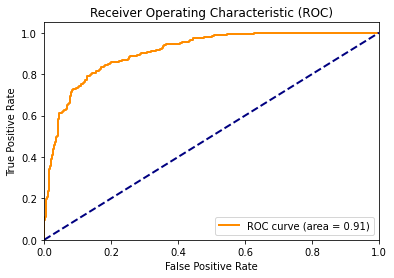

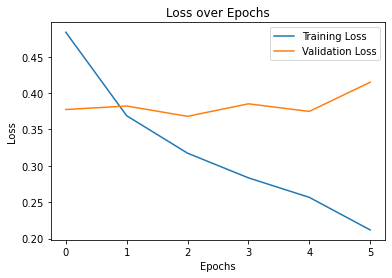

Accuracy: 0.81625
Precision: 0.7756563245823389
Recall: 0.8597883597883598
F1 Score: 0.8155583437892095
Confusion Matrix:
[[328  94]
 [ 53 325]]
Cohen's Kappa: 0.6334575920407934
Matthews Correlation: 0.6367940815374059
Balanced Accuracy: 0.8185197723112415
True Positives: 325
True Negatives: 328
False Positives: 94
False Negatives: 53
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8147 - loss: 0.4001
Test Accuracy: 81.63%
Test Loss: 40.38%
Execution time: 793.9913187026978
Metrics appended to metrics.csv file.


In [6]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import cv2
import time
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Start time
start_time = time.time()
# Assuming you have X_train, X_test, y_train, and y_test
# Modify the data shapes based on the model requirements
X_train_resized = np.array([cv2.resize(img, (224, 224)) for img in X_train])
X_train_resized = np.repeat(X_train_resized[..., np.newaxis], 3, -1)
X_valid_resized = np.array([cv2.resize(img, (224, 224)) for img in X_valid])
X_valid_resized = np.repeat(X_valid_resized[..., np.newaxis], 3, -1)
# Example: Assuming X_test is another dataset
X_test_resized = np.array([cv2.resize(img, (224, 224)) for img in X_test])
X_test_resized = np.repeat(X_test_resized[..., np.newaxis], 3, -1)


# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=output)


# Compile the model with Adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)



# Train the model with early stopping and 10 epochs (change as needed)
history = model.fit(X_train_resized, y_train, batch_size=32, epochs=25, validation_data=(X_valid_resized, y_valid), callbacks=[early_stopping])

# Predict probabilities for test labels
predicted_probabilities = model.predict(X_test_resized)

# Convert probabilities to classes (0 or 1)
predicted_labels = (predicted_probabilities > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels)
recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
conf_matrix = confusion_matrix(y_test, predicted_labels)


# Calculate additional metrics
kappa = cohen_kappa_score(y_test, predicted_labels)
mcc = matthews_corrcoef(y_test, predicted_labels)
balanced_accuracy = balanced_accuracy_score(y_test, predicted_labels)

# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = confusion_matrix(y_test, predicted_labels).ravel()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities)
roc_auc = auc(fpr, tpr)


# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot loss and epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Print Metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print(f"Cohen's Kappa: {kappa}")
print(f"Matthews Correlation: {mcc}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss * 100:.2f}%')

# Measure the end time
end_time = time.time()
execution_time = end_time - start_time

print("Execution time:", execution_time)

# Load the existing metrics.csv file into a DataFrame
existing_metrics_df = pd.read_csv('VGG16_2000_epoch_25_metrics.csv')
# Create a DataFrame with the new metrics and execution time
new_metrics_dict = {
    'Combination': ['4'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'Test Accuracy': [test_accuracy * 100],
    'Test Loss': [test_loss * 100],
    'Validation Accuracy': history.history['val_accuracy'][-1],
    'Validation Loss': history.history['val_loss'][-1],
    'Cohen\'s Kappa': [kappa],
    'Matthews Correlation': [mcc],
    'Balanced Accuracy': [balanced_accuracy],
    'True Positives': [tp],
    'True Negatives': [tn],
    'False Positives': [fp],
    'False Negatives': [fn],
    'Execution Time (s)': [execution_time]
}

new_metrics_df = pd.DataFrame(new_metrics_dict)

# Concatenate the existing DataFrame with the new DataFrame
updated_metrics_df = pd.concat([existing_metrics_df, new_metrics_df], ignore_index=True)

# Save the updated DataFrame back to the CSV file
updated_metrics_df.to_csv('VGG16_2000_epoch_25_metrics.csv', index=False)

print("Metrics appended to metrics.csv file.")

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           51

 Total params: 15,342,529 (58.53 MB)

 Trainable params: 627,841 (2.40 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6624 - loss: 0.6424 - val_accuracy: 0.8281 - val_loss: 0.4201
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8139 - loss: 0.3988 - val_accuracy: 0.8562 - val_loss: 0.3601
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8084 - loss: 0.3927 - val_accuracy: 0.8219 - val_loss: 0.4102
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8632 - loss: 0.3406 - val_accuracy: 0.8375 - val_loss: 0.3583
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8584 - loss: 0.3177 - val_accuracy: 0.8313 - val_loss: 0.3522
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8784 - loss: 0.2800 - val_accuracy: 0.8406 - val_loss: 0.3628
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8844 - loss: 0.2724 - val_accuracy: 0.8313 - val_loss: 0.4119
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8975 - loss: 0.2527 - val_accuracy: 0.8656 - v

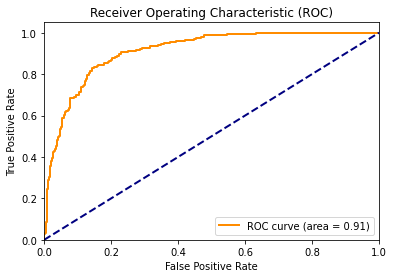

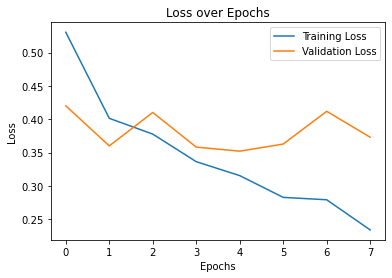

Accuracy: 0.835
Precision: 0.847457627118644
Recall: 0.7936507936507936
F1 Score: 0.819672131147541
Confusion Matrix:
[[368  54]
 [ 78 300]]
Cohen's Kappa: 0.6678994641104989
Matthews Correlation: 0.6691203763081753
Balanced Accuracy: 0.8328443541713684
True Positives: 300
True Negatives: 368
False Positives: 54
False Negatives: 78
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8364 - loss: 0.3700
Test Accuracy: 83.50%
Test Loss: 38.29%
Execution time: 1050.781489610672
Metrics appended to metrics.csv file.


In [7]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import cv2
import time
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Start time
start_time = time.time()
# Assuming you have X_train, X_test, y_train, and y_test
# Modify the data shapes based on the model requirements
X_train_resized = np.array([cv2.resize(img, (224, 224)) for img in X_train])
X_train_resized = np.repeat(X_train_resized[..., np.newaxis], 3, -1)
X_valid_resized = np.array([cv2.resize(img, (224, 224)) for img in X_valid])
X_valid_resized = np.repeat(X_valid_resized[..., np.newaxis], 3, -1)
# Example: Assuming X_test is another dataset
X_test_resized = np.array([cv2.resize(img, (224, 224)) for img in X_test])
X_test_resized = np.repeat(X_test_resized[..., np.newaxis], 3, -1)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=output)


# Compile the model with Adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)


# Train the model with early stopping and 10 epochs (change as needed)
history = model.fit(X_train_resized, y_train, batch_size=32, epochs=25, validation_data=(X_valid_resized, y_valid), callbacks=[early_stopping])

# Predict probabilities for test labels
predicted_probabilities = model.predict(X_test_resized)

# Convert probabilities to classes (0 or 1)
predicted_labels = (predicted_probabilities > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels)
recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
conf_matrix = confusion_matrix(y_test, predicted_labels)


# Calculate additional metrics
kappa = cohen_kappa_score(y_test, predicted_labels)
mcc = matthews_corrcoef(y_test, predicted_labels)
balanced_accuracy = balanced_accuracy_score(y_test, predicted_labels)

# True Positives, True Negatives, False Positives, False Negatives
tn, fp, fn, tp = confusion_matrix(y_test, predicted_labels).ravel()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities)
roc_auc = auc(fpr, tpr)


# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot loss and epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Print Metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print(f"Cohen's Kappa: {kappa}")
print(f"Matthews Correlation: {mcc}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss * 100:.2f}%')

# Measure the end time
end_time = time.time()
execution_time = end_time - start_time

print("Execution time:", execution_time)

# Load the existing metrics.csv file into a DataFrame
existing_metrics_df = pd.read_csv('VGG16_2000_epoch_25_metrics.csv')
# Create a DataFrame with the new metrics and execution time
new_metrics_dict = {
    'Combination': ['5'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'Test Accuracy': [test_accuracy * 100],
    'Test Loss': [test_loss * 100],
    'Validation Accuracy': history.history['val_accuracy'][-1],
    'Validation Loss': history.history['val_loss'][-1],
    'Cohen\'s Kappa': [kappa],
    'Matthews Correlation': [mcc],
    'Balanced Accuracy': [balanced_accuracy],
    'True Positives': [tp],
    'True Negatives': [tn],
    'False Positives': [fp],
    'False Negatives': [fn],
    'Execution Time (s)': [execution_time]
}

new_metrics_df = pd.DataFrame(new_metrics_dict)

# Concatenate the existing DataFrame with the new DataFrame
updated_metrics_df = pd.concat([existing_metrics_df, new_metrics_df], ignore_index=True)

# Save the updated DataFrame back to the CSV file
updated_metrics_df.to_csv('VGG16_2000_epoch_25_metrics.csv', index=False)


print("Metrics appended to metrics.csv file.")
